In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

file_path = r"C:\Users\Prema\Downloads\archive (3)\spam.csv"
df = pd.read_csv(file_path, encoding='latin-1')

print(df.head())
print(df.columns)

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')


In [38]:
df = pd.read_csv(r"C:\Users\Prema\Downloads\archive (3)\spam.csv", encoding='latin-1')
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])
df.columns = ['label', 'message']
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(df.head())


   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [39]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df['message'], df['label'], test_size=0.2, random_state=42)
vectorizer = TfidfVectorizer(stop_words='english')

# Convert text to numerical data
vectorizer = TfidfVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [40]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)
predictions = model.predict(X_test_vec)
print(f"Accuracy: {accuracy_score(y_test, predictions)}")

Accuracy: 0.9668161434977578


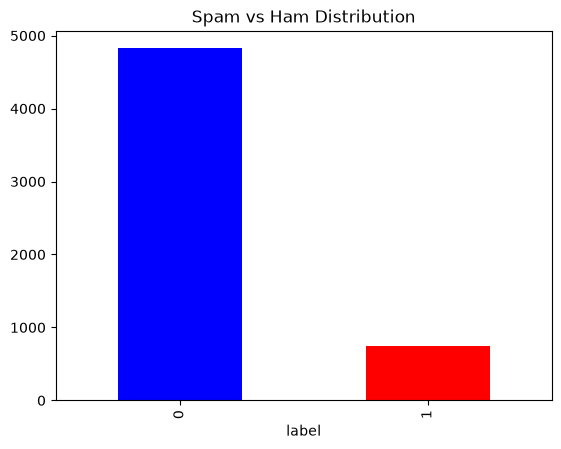

In [41]:
import matplotlib.pyplot as plt
df['label'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Spam vs Ham Distribution')
plt.show()

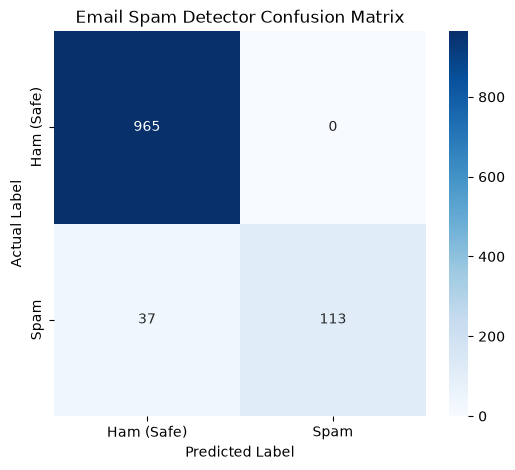

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the matrix
cm = confusion_matrix(y_test, predictions)

# Plotting the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham (Safe)', 'Spam'], 
            yticklabels=['Ham (Safe)', 'Spam'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Email Spam Detector Confusion Matrix')
plt.show()